In [1]:
import pandas, urllib, numpy

In [2]:
import statsmodels, statsmodels.stats, statsmodels.stats.multitest

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
# pip install git+https://github.com/Maayanlab/maayanlab-bioinformatics.git
import maayanlab_bioinformatics, maayanlab_bioinformatics.enrichment

# define library

In [5]:
enrichr_library = 'Reactome_Pathways_2024'

# read data

In [6]:
gene_list_input = ['GBP6', 'GBP8', 'WFDC21', 'SP110', 'KRT5', 'MX1', 'RSAD2', 'GVIN-PS7', 'MX2', 'CIDEC', 'H2-AA', 'PSMB9', 'ASS1', 'SHTN1', 'CAPN11', 'IGTP', 'CDO1', 'LEF1', 'STXBP2', 'C3AR1', 'AQP3', 'LY6C2', 'MUC1', 'TRBC1', 'TRBC2', 'S100A14', 'LY6G6C', 'GBP3', 'GBP5', 'EPSTI1', 'H2-D1', 'ST14', 'IFI44', 'GJB3', 'PLBD1', 'SPRR1A', 'RAPGEFL1', 'LY9', 'GVIN1', 'IFIT1', 'GVIN2', 'IFIT3', 'C3', 'RNF213', 'ART3', 'LGALS3', 'KLRK1', 'PLAC8', 'RASSF7', 'PLCG2', 'SFN', 'TNS4', 'OASL1', 'LGALS7', 'OASL2', 'CCR2', 'SLC10A6', 'KRT14', 'GM57322', 'GM50012', 'BST2', 'TTLL7', 'PTPRC', 'THEMIS2', 'SIGLEC1', 'KRT17', 'DPYD', 'KRT16', 'ARHGEF4', 'RAPSN', 'EBI3', 'PHF11A', 'OAS1A', 'STC2', 'PHF11B', 'OAS1B', 'OAS1C', 'TNFRSF11B', 'IIGP1C', 'MS4A4C', 'OAS1G', 'KLK7', 'PHF11D', 'CTSS', 'MS4A4B', 'SOCS3', 'EPCAM', 'CLEC7A', 'COL10A1', 'EMB', 'CCR5', 'ADIPOQ', 'CD52', 'EGLN3', 'TGTP2', 'DGAT2', 'CD180', 'VAX2', 'ASPRV1', 'GATM', 'LRATD1', 'F2RL1', 'CMPK2', 'CD48', 'PTPRCAP', 'LRRC15', 'LAD1', 'TCSTV4', 'IFIH1', 'FHIP1A', 'GPNMB', 'ANXA8', 'IFI209', 'ZBP1', 'CD74', 'MREG', 'LAG3', 'CORO2A', 'IFI208', 'CD72', 'IFI206', 'CYBRD1', 'TMEM252', 'CXCL10', 'FCGR1', 'GM27029', 'FCGR4', 'LY6A', 'PKP3', 'IFIT3B', 'LY6D', 'KLRD1', 'PKP1', '9630013D21RIK', 'SLFN8', 'SLFN2', 'H2-K1', 'HP', 'SLFN4', 'GIMAP3', 'TRP63', 'PRDM1', 'IFI213', 'GPR65', 'HR', 'SBSN', 'TSPAN32', 'KRT6A', 'WIF1', 'CDH1', 'H2-DMB2', 'PERP', 'RAB25', 'SLFN1', 'IGFBP2', 'IIGP1', 'PSAPL1', 'CYBB', 'ISG15', 'SELP', 'EFNA3', 'COL6A5', 'XAF1', 'FGFR3', 'H2-AB1', 'CD274', 'LGALS3BP', 'TACSTD2', 'DDX60', 'C1QTNF3', 'GLIPR1', 'VDR', 'URAH', 'CD24A', 'OAS2', 'OAS3', 'COL7A1', 'PLCH2', 'SERINC2', 'IRF7', 'IFI27L2A', 'ZFP991', 'GM14322', 'CXCL9', 'PTPN22', 'HSPB1', 'KLC3', 'RASGEF1B', 'GM28967', 'TCFL5', 'IRX2', 'DSP', 'LSR', 'SORL1', 'KLF4', 'GM56730', 'TPD52L1', 'ALDH1A7', 'CLDN4', 'EVI2B', 'APOC1', 'LTB', 'NECTIN4', 'MYO1G', 'SNED1', 'TRIM30A', 'H2-T24', 'H2-T23', 'APOL9B', 'RTP4', 'KRT80', 'APOL9A', 'TRIM30D', 'CLEC12A', 'H2-Q7', 'H2-Q5', 'H2-Q6', 'DMKN', 'H2-Q4', 'USP18', 'ENDOU', 'CKMT1', 'TRIM29', 'PPP1R13L', 'DHX58', 'ZIC1', 'CCL5', 'ITGAX', 'EPS8L2', 'SERPINB9B']
print(len(gene_list_input))

230


In [7]:
df = pandas.read_csv('029 orsay Table DEGs - VGA.tsv', sep='\t')
original = df['Gene name'].values
gene_list_input = [element.upper() for element in original]
print(len(gene_list_input), gene_list_input[:10])

230 ['RTP4', 'USP18', 'OASL2', 'IFIT1', 'GBP3', 'IRF7', 'GATM', 'IFIT3', 'GBP5', 'RNF213']


In [8]:
def get_library(lib_name):
    '''
    Returns a dictionary mapping each term from the input library to 
    its associated geneset. 
    '''
    raw_lib_data = []

    with urllib.request.urlopen('https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=' + lib_name) as f:
        for line in f.readlines():
            raw_lib_data.append(line.decode("utf-8").split("\t\t"))

    name = []
    gene_list = []
    lib_data = {}

    for i in range(len(raw_lib_data)):
        name += [raw_lib_data[i][0]]
        raw_genes = raw_lib_data[i][1].replace('\t', ' ')
        gene_list += [raw_genes[:-1]]
    
    lib_data = {a[0]:a[1].split(' ') for a in zip(name, gene_list)}
    return lib_data

lib_data = get_library(enrichr_library)

enrich_results = maayanlab_bioinformatics.enrichment.enrich_crisp(gene_list_input, lib_data, 21000, True)

res_df = pandas.DataFrame(
    [ [
        term, 
        res.pvalue, 
        res.odds_ratio,
        res.n_overlap,

    ] for (term, res) in enrich_results ], 
    columns=['term', 'pvalue', 'odds_ratio', 'n_overlap']
)
res_df

,term,pvalue,odds_ratio,n_overlap
0,AMPK Inhibits chREBP Transcriptional Activatio...,0.094379,11.332969,1
1,Activation of BAD and Translocation to Mitocho...,0.161607,6.042213,1
2,Activation of BH3-only Proteins,0.289398,3.018923,1
3,Activation of C3 and C5,0.084346,12.952589,1
4,"Activation of IRF3, IRF7 Mediated by TBK1, IKK...",0.188875,5.034449,1
...,...,...,...,...
433,Viral Infection Pathways,0.810885,0.778092,9
434,Vitamin D (Calciferol) Metabolism,0.133426,7.553857,1
435,ZBP1(DAI) Mediated Induction of Type I IFNs,0.215261,4.314618,1
436,P75 NTR Receptor-Mediated Signalling,0.664735,0.921130,1


In [9]:
# add gene names
container = []
for pathway in res_df['term']:
    
    overlap_genes = []
    for query in lib_data[pathway]:
        if query in gene_list_input:
            overlap_genes.append(query)
    mouse_overlap_genes = [element.lower().title() for element in overlap_genes]
    overlap_genes_string = ', '.join(mouse_overlap_genes)
    container.append(overlap_genes_string)

res_df.loc[:, 'overlap_genes'] = container
res_df

,term,pvalue,odds_ratio,n_overlap,overlap_genes
0,AMPK Inhibits chREBP Transcriptional Activatio...,0.094379,11.332969,1,Adipoq
1,Activation of BAD and Translocation to Mitocho...,0.161607,6.042213,1,Sfn
2,Activation of BH3-only Proteins,0.289398,3.018923,1,Sfn
3,Activation of C3 and C5,0.084346,12.952589,1,C3
4,"Activation of IRF3, IRF7 Mediated by TBK1, IKK...",0.188875,5.034449,1,Irf7
...,...,...,...,...,...
433,Viral Infection Pathways,0.810885,0.778092,9,"Sfn, Bst2, Ccr5, Zbp1, Isg15, Irf7, Plcg2, Ifi..."
434,Vitamin D (Calciferol) Metabolism,0.133426,7.553857,1,Vdr
435,ZBP1(DAI) Mediated Induction of Type I IFNs,0.215261,4.314618,1,Zbp1
436,P75 NTR Receptor-Mediated Signalling,0.664735,0.921130,1,Arhgef4


In [10]:
# multiple test correction
results = statsmodels.stats.multitest.multipletests(res_df['pvalue'], alpha=0.05, method='fdr_bh')
res_df['adjusted'] = results[1]

(426, 6)
(12, 6)
1	1.241473654374876	Immune System	1.2743205917777885e-07
2	1.1736820083402149	Interferon Alpha Beta Signaling	1.4180257569056677e-09
3	1.0016604530948996	Apoptotic Cleavage of Cell Adhesion Proteins	0.012906248600587327
4	0.7183334281099127	Cytokine Signaling in Immune System	3.5583573899619897e-06
5	0.6456425819151974	Formation of the Cornified Envelope	2.262460705741733e-06
6	0.638773812734261	Interferon Signaling	2.262460705741733e-06
7	0.4599865081902162	Innate Immune System	0.008703167045897952
8	0.3321473049420492	Keratinization	0.000397293998006577
9	0.31126438713682864	Interferon Gamma Signaling	0.0008981180027125603
10	0.23167234070290707	Chemokine Receptors Bind Chemokines	0.018880484215052538


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_2699/527594541.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.loc[:, 'importance'] = importance


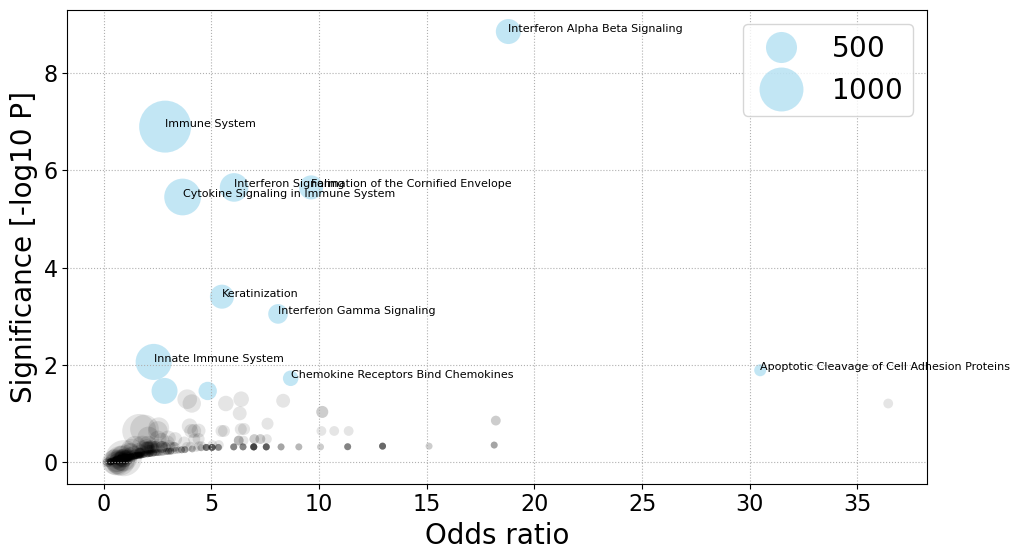

In [13]:
# plot

def importance_calculator(x, y, w):

    xnorm = (x - numpy.min(x)) / (numpy.max(x) - numpy.min(x))
    ynorm = (y - numpy.min(y)) / (numpy.max(y) - numpy.min(y))
    wnorm = (w - numpy.min(w)) / (numpy.max(w) - numpy.min(w))

    importance = [numpy.sqrt(xnorm[i]**2 + ynorm[i]**2 + wnorm[i]**2) for i in range(len(x))]
    return importance

inflation = 25

a = res_df[(res_df['adjusted'] > 0.05) | (res_df['odds_ratio'] < 2)]
print(a.shape)
x = a['odds_ratio']
y = -numpy.log10(a['adjusted'])
s = a['n_overlap']
matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/10, edgecolors='none', color='black')

b = res_df[(res_df['adjusted'] < 0.05) & (res_df['odds_ratio'] > 2)]
print(b.shape)
x = b['odds_ratio']
y = -numpy.log10(b['adjusted'])
s = b['n_overlap']
sc = matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/2, edgecolors='none', color='skyblue')

x = list(b['odds_ratio'])
y = list(-numpy.log10(b['adjusted']))
prez = list(b['term'].values)
z = [element.split()[-1] for element in prez]
importance = importance_calculator(x, y, s.values)
b.loc[:, 'importance'] = importance
c = b.sort_values('importance', ascending=False)

threshold = importance[numpy.argsort(importance)[::-1][10]] # gimme the top 10
com = c[c['importance'] > threshold]
count = 0
for index, row in com.iterrows():
    x = row['odds_ratio']
    y = -numpy.log10(row['adjusted'])
    
    label = ' '.join(row['term'].split()[:2])
    label = row['term']
    matplotlib.pyplot.text(x, y, label, fontsize=8)
    count = count + 1
    print('{}\t{}\t{}\t{}'.format(count, row['importance'], row['term'], row['adjusted']))

matplotlib.pyplot.legend(*sc.legend_elements("sizes", num=3, color='skyblue', alpha=1/2, mew=0))
matplotlib.pyplot.xlabel('Odds ratio')
matplotlib.pyplot.ylabel('Significance [-log10 P]')
matplotlib.pyplot.grid(ls=':', alpha=1)
matplotlib.pyplot.tight_layout()

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('vga.svg')

In [12]:
# store list 
print(c.shape)
c.drop('pvalue', axis='columns', inplace=True)
d = c.iloc[:, [0, 5, 4, 1, 2, 3]]
d.rename(columns={"term": "Term", 
                  "importance": "Priority", 
                  'adjusted':'Adjusted P', 
                  'odds_ratio':'Odds ratio',
                 'n_overlap':'N overlap',
                 'overlap_genes':'Overlap genes'}, inplace=True)
d.set_index('Term', inplace=True)
d.head()
d.to_csv('vga.wikipathways.tsv', sep='\t')

d

(12, 7)


,Priority,Adjusted P,Odds ratio,N overlap,Overlap genes
Term,,,,,
Immune System,1.241474,1.274321e-07,2.858274,56,"C3Ar1, Rnf213, Siglec1, Pkp1, Cd274, Trim29, I..."
Interferon Alpha Beta Signaling,1.173682,1.418026e-09,18.792906,13,"Mx1, Mx2, Rsad2, Bst2, Oas2, Oas3, Irf7, Socs3..."
Apoptotic Cleavage of Cell Adhesion Proteins,1.001660,1.290625e-02,30.486050,3,"Dsp, Cdh1, Pkp1"
Cytokine Signaling in Immune System,0.718333,3.558357e-06,3.669600,28,"Gbp6, Muc1, Gbp3, Gbp5, Cxcl10, Trim29, Ccl5, ..."
Formation of the Cornified Envelope,0.645643,2.262461e-06,9.633961,12,"Krt5, Pkp3, Pkp1, Krt6A, Perp, St14, Sprr1A, K..."
Interferon Signaling,0.638774,2.262461e-06,6.059816,17,"Gbp6, Mx1, Mx2, Rsad2, Gbp3, Gbp5, Ifit1, Ifit..."
Innate Immune System,0.459987,8.703167e-03,2.326935,27,"C3Ar1, Muc1, C3, Klrk1, Pkp1, Hp, Glipr1, Dsp,..."
Keratinization,0.332147,3.972940e-04,5.494967,12,"Krt5, St14, Sprr1A, Krt14, Krt17, Krt16, Pkp3,..."
Interferon Gamma Signaling,0.311264,8.981180e-04,8.099491,8,"Gbp6, Gbp3, Gbp5, Oas2, Oas3, Irf7, Socs3, Trim29"
